## Importando os dados preparados

In [1]:
import joblib

partitions, anomalyColumns = joblib.load("./dados_preparados.pkl")

## Importando os pipelines

In [2]:
pipelines = joblib.load("./pipelines.pkl")
print(list(pipelines))

['IF', 'OCSVM', 'LOF']


## Imports

In [3]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.base import BaseEstimator, clone
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import roc_curve
from sklearn.pipeline import Pipeline

from anomaly_utils import (anomalyScores, binaryMetrics, combinePartitions, evaluateQ95, extremeCases,
                           scoreSummary, selectCandidate, transition)

RANDOM_STATE = 42
TEXT_COLUMN = "text"

# Treinamento dos modelos

## Latent Dirichlet Allocation

O LDA é um modelo de tópicos: aprende `k` tópicos (distribuições sobre palavras) e representa cada
notícia como uma mistura desses tópicos. Aqui ele vira um detector de anomalias:

- Vocabulário (`CountVectorizer`) e tópicos são ajustados **somente com `normalTrain`** (True).
- `decision_function` = log-verossimilhança média por palavra da notícia sob os tópicos True,
  `log p(w|d) = log Σ_k θ_dk · φ_kw`. O `anomalyScore = -decision_function` é a log-perplexidade:
  maior = vocabulário/assuntos menos compatíveis com as notícias True.
- Usa o mesmo prefixo de `CHARACTER_LIMIT` caracteres (`text`) das demais features, então o
  comprimento original não vaza para o score. Palavras fora do vocabulário do treino são ignoradas.
- Sem lista de stopwords em português nas dependências, `max_df=0.1` descarta palavras presentes em
  mais de 10% das True de treino (artigos, preposições), deixando tópicos temáticos legíveis.
- O LDA não tem fronteira nativa; só a regra q95 (calibrada nas True de validação) é avaliada.

Candidatos: `n_components` ∈ {5, 10, 20, 40}. Escolha na validação: ROC-AUC → AP → menor `n_components`.

In [4]:
class TopicLikelihoodDetector(BaseEstimator):
    """LDA ajustado em contagens; decision_function = log-verossimilhança média por palavra."""

    def __init__(self, n_components=10, max_iter=30, random_state=RANDOM_STATE):
        self.n_components = n_components
        self.max_iter = max_iter
        self.random_state = random_state

    def fit(self, X, y=None):
        self.lda_ = LatentDirichletAllocation(
            n_components=self.n_components, learning_method="batch", max_iter=self.max_iter,
            random_state=self.random_state, n_jobs=1,
        ).fit(X)
        self.topicWord_ = self.lda_.components_ / self.lda_.components_.sum(axis=1, keepdims=True)
        return self

    def decision_function(self, X):
        X = X.tocoo()
        documentTopic = self.lda_.transform(X.tocsr())
        wordProbability = np.einsum("ij,ji->i", documentTopic[X.row], self.topicWord_[:, X.col])
        logLikelihood = np.bincount(X.row, weights=X.data * np.log(wordProbability), minlength=X.shape[0])
        wordCounts = np.bincount(X.row, weights=X.data, minlength=X.shape[0])
        # Notícia sem nenhuma palavra do vocabulário recebe a verossimilhança de um vocabulário uniforme.
        uniform = -np.log(self.topicWord_.shape[1])
        return np.where(wordCounts > 0, logLikelihood / np.maximum(wordCounts, 1), uniform)


def buildLdaPipeline(nComponents):
    return Pipeline([
        ("vectorizer", CountVectorizer(token_pattern=r"(?u)\b[^\d\W]{2,}\b", min_df=2, max_df=0.1)),
        ("detector", TopicLikelihoodDetector(n_components=nComponents)),
    ])


ldaCandidates = {f"lda_topics_{k:03d}": buildLdaPipeline(k) for k in [5, 10, 20, 40]}
list(ldaCandidates)

['lda_topics_005', 'lda_topics_010', 'lda_topics_020', 'lda_topics_040']

`fitNormalOnly` do `anomaly_utils` verifica o imputer das features numéricas, que não existe
neste pipeline de texto. A função abaixo aplica o mesmo contrato (só True no fit, IDs do fit
bloqueados para pontuação) e reaproveita `anomalyScores`/`binaryMetrics` do módulo.

In [5]:
def fitNormalOnlyText(pipeline, trainingFrame):
    if trainingFrame.empty or not trainingFrame["label"].eq(0).all():
        raise ValueError("Treino permitido apenas com notícias True (label == 0).")
    if trainingFrame[TEXT_COLUMN].isna().any():
        raise ValueError("Textos ausentes em normalTrain.")
    pipeline.fit(trainingFrame[TEXT_COLUMN])
    pipeline._normalTrainIds = frozenset(trainingFrame["id"].astype(str))
    return pipeline


validationFrame = combinePartitions(partitions, "Validation")
validationLabels = validationFrame["label"].to_numpy(dtype=int)
fittedPipelines, records = {}, []
for modelKey, pipeline in ldaCandidates.items():
    fitStarted = time.perf_counter()
    pipeline = fitNormalOnlyText(clone(pipeline), partitions["normalTrain"])
    fitSeconds = time.perf_counter() - fitStarted
    normalValidationScores = anomalyScores(pipeline, partitions["normalValidation"], TEXT_COLUMN)
    validationScores = anomalyScores(pipeline, validationFrame, TEXT_COLUMN)
    q95Threshold = float(np.quantile(normalValidationScores, 0.95))
    q95 = binaryMetrics(validationLabels, validationScores, validationScores >= q95Threshold)
    normalValidationCounts = pipeline["vectorizer"].transform(partitions["normalValidation"][TEXT_COLUMN])
    records.append({
        "modelKey": modelKey,
        "n_components": pipeline["detector"].n_components,
        "vocabularySize": len(pipeline["vectorizer"].vocabulary_),
        "normalValidationPerplexity": float(pipeline["detector"].lda_.perplexity(normalValidationCounts)),
        "fitSeconds": fitSeconds,
        "q95Threshold": q95Threshold,
        "normalValidationQ95AlertRate": float(np.mean(normalValidationScores >= q95Threshold)),
        "validationRocAuc": q95["rocAuc"],
        "validationAveragePrecision": q95["averagePrecision"],
        "q95Metrics": q95,
    })
    fittedPipelines[modelKey] = pipeline
validationResults = pd.DataFrame(records)

selectedModelKey = selectCandidate(validationResults, "n_components")
display(validationResults.drop(columns=["q95Metrics"]))
print("Candidato LDA congelado antes do teste:", selectedModelKey)

,modelKey,n_components,vocabularySize,normalValidationPerplexity,fitSeconds,q95Threshold,normalValidationQ95AlertRate,validationRocAuc,validationAveragePrecision
0,lda_topics_005,5,5840,8515.034873,9.864546,8.254102,0.05,0.601760,0.764742
1,lda_topics_010,10,5840,19036.451724,8.885918,8.144857,0.05,0.593140,0.762084
2,lda_topics_020,20,5840,60296.287694,8.133092,8.013170,0.05,0.595596,0.756061
3,lda_topics_040,40,5840,286661.990680,8.108181,7.801184,0.05,0.589779,0.754215


Candidato LDA congelado antes do teste: lda_topics_005


## Tópicos aprendidos

Palavras de maior peso em cada tópico do candidato selecionado (aprendidos só com True).

In [6]:
selectedPipeline = fittedPipelines[selectedModelKey]
vocabulary = selectedPipeline["vectorizer"].get_feature_names_out()
topicWord = selectedPipeline["detector"].topicWord_
pd.DataFrame(
    {f"topico_{topic:02d}": vocabulary[np.argsort(weights)[::-1][:10]] for topic, weights in enumerate(topicWord)}
).T

,0,1,2,3,4,5,6,7,8,9
topico_00,norte,coreia,eua,trump,estados,aécio,dilma,americano,unidos,mas
topico_01,juiz,moro,defesa,estão,principais,você,bem,notícias,aqui,pedido
topico_02,lava,jato,operação,ministério,delação,pela,pf,corrupção,ministro,geral
topico_03,governo,câmara,ministro,contra,stf,rio,michel,senado,brasília,ano
topico_04,pessoas,das,polícia,desta,segunda,rio,tem,país,brasil,ano


## Avaliação no teste e comparação com Isolation Forest, One-Class SVM e LOF

Os controles usam o mesmo `normalTrain`, partições e regra q95, com as features estilométricas.
OCSVM é o candidato `nu=0.10` e LOF o `n_neighbors=80` congelado no 04_LOF; nenhum controle é
reajustado no teste. O q95 do LDA é recalculado com o candidato já ajustado, sem novo fit.

In [7]:
def evaluateTextQ95(pipeline, partitions):
    normalValidationScores = anomalyScores(pipeline, partitions["normalValidation"], TEXT_COLUMN)
    threshold = float(np.quantile(normalValidationScores, 0.95))
    testFrame = combinePartitions(partitions, "Test")
    scores = anomalyScores(pipeline, testFrame, TEXT_COLUMN)
    q95Flags = scores >= threshold
    return {
        "pipeline": pipeline, "threshold": threshold, "testFrame": testFrame,
        "scores": scores, "q95Flags": q95Flags,
        "q95Metrics": binaryMetrics(testFrame["label"].to_numpy(dtype=int), scores, q95Flags),
    }


results = {
    "lda": evaluateTextQ95(selectedPipeline, partitions),
    "isolationForest": evaluateQ95(pipelines["IF"], partitions, anomalyColumns),
    "ocsvm": evaluateQ95(pipelines["OCSVM"]["ocsvm_nu_010"], partitions, anomalyColumns),
    "lof": evaluateQ95(pipelines["LOF"]["lof_neighbors_080"], partitions, anomalyColumns),
}
assert all(results["lda"]["testFrame"]["id"].equals(result["testFrame"]["id"]) for result in results.values())

testPredictionsFrame = results["lda"]["testFrame"][["id", "label", "partition", TEXT_COLUMN] + anomalyColumns].copy()
for model, result in results.items():
    testPredictionsFrame[f"{model}AnomalyScore"] = result["scores"]
    testPredictionsFrame[f"{model}Q95IsAnomaly"] = result["q95Flags"]

transitionPairs = {
    "ldaVsIsolationForest": ("lda", "isolationForest"),
    "ldaVsOcsvm": ("lda", "ocsvm"),
    "ldaVsLof": ("lda", "lof"),
}
for column, (left, right) in transitionPairs.items():
    testPredictionsFrame[column] = transition(results[left]["q95Flags"], results[right]["q95Flags"], left, right)
transitionColumns = list(transitionPairs)

display(pd.DataFrame({f"{model} q95": result["q95Metrics"] for model, result in results.items()}).T)
display(pd.concat({
    model: scoreSummary(testPredictionsFrame, f"{model}AnomalyScore") for model in results
}, names=["model", "label"]))
testPredictionsFrame.groupby(["label"] + transitionColumns).size().rename("count").reset_index()

,rocAuc,averagePrecision,fakePrevalence,tn,fp,fn,tp,accuracy,precision,recall,f1,fpr
lda q95,0.598409,0.762547,0.714286,683.0,37.0,1689.0,111.0,0.315079,0.750000,0.061667,0.113963,0.051389
isolationForest q95,0.980673,0.988672,0.714286,699.0,21.0,31.0,1769.0,0.979365,0.988268,0.982778,0.985515,0.029167
ocsvm q95,0.976384,0.985442,0.714286,693.0,27.0,145.0,1655.0,0.931746,0.983948,0.919444,0.950603,0.037500
lof q95,0.987400,0.993869,0.714286,694.0,26.0,31.0,1769.0,0.977381,0.985515,0.982778,0.984145,0.036111


class  count       mean     median       std       min  \
model           label                                                          
lda             0      True    720   7.517012   7.540222  0.470839  6.122475   
                1      Fake   1800   7.676626   7.685555  0.394217  6.409407   
isolationForest 0      True    720  -0.058204  -0.076152  0.061314 -0.125163   
                1      Fake   1800   0.148692   0.142426  0.037844 -0.124589   
ocsvm           0      True    720  -1.148508  -1.587920  2.789851 -3.769342   
                1      Fake   1800  10.892979  10.240216  5.719358 -3.779833   
lof             0      True    720  -0.357812  -0.454499  0.475691 -0.541515   
                1      Fake   1800   3.506991   3.304370  1.399329 -0.528835   

                             max  
model           label             
lda             0       8.771150  
                1       9.156377  
isolationForest 0       0.212721  
                1       0.261826  
ocsvm           0      21.352744  
                1      23.014737  
lof             0       5.316613  
                1       6.717459

,label,ldaVsIsolationForest,ldaVsOcsvm,ldaVsLof,count
0,0,alerta_adicionado_isolationForest,alerta_adicionado_ocsvm,alerta_adicionado_lof,18
1,0,alerta_adicionado_isolationForest,alerta_adicionado_ocsvm,sem_alerta,1
2,0,alerta_adicionado_lda,alerta_adicionado_lda,alerta_adicionado_lda,35
3,0,alerta_mantido,alerta_mantido,alerta_mantido,2
4,0,sem_alerta,alerta_adicionado_ocsvm,alerta_adicionado_lof,5
5,0,sem_alerta,alerta_adicionado_ocsvm,sem_alerta,1
6,0,sem_alerta,sem_alerta,alerta_adicionado_lof,1
7,0,sem_alerta,sem_alerta,sem_alerta,657
8,1,alerta_adicionado_isolationForest,alerta_adicionado_ocsvm,alerta_adicionado_lof,1552
9,1,alerta_adicionado_isolationForest,sem_alerta,alerta_adicionado_lof,108


## Visualizações

As figuras são diagnósticas: não são importância de feature nem explicação causal. A mistura média
de tópicos por classe mostra quais assuntos True as notícias Fake de teste ocupam (ou deixam de ocupar).

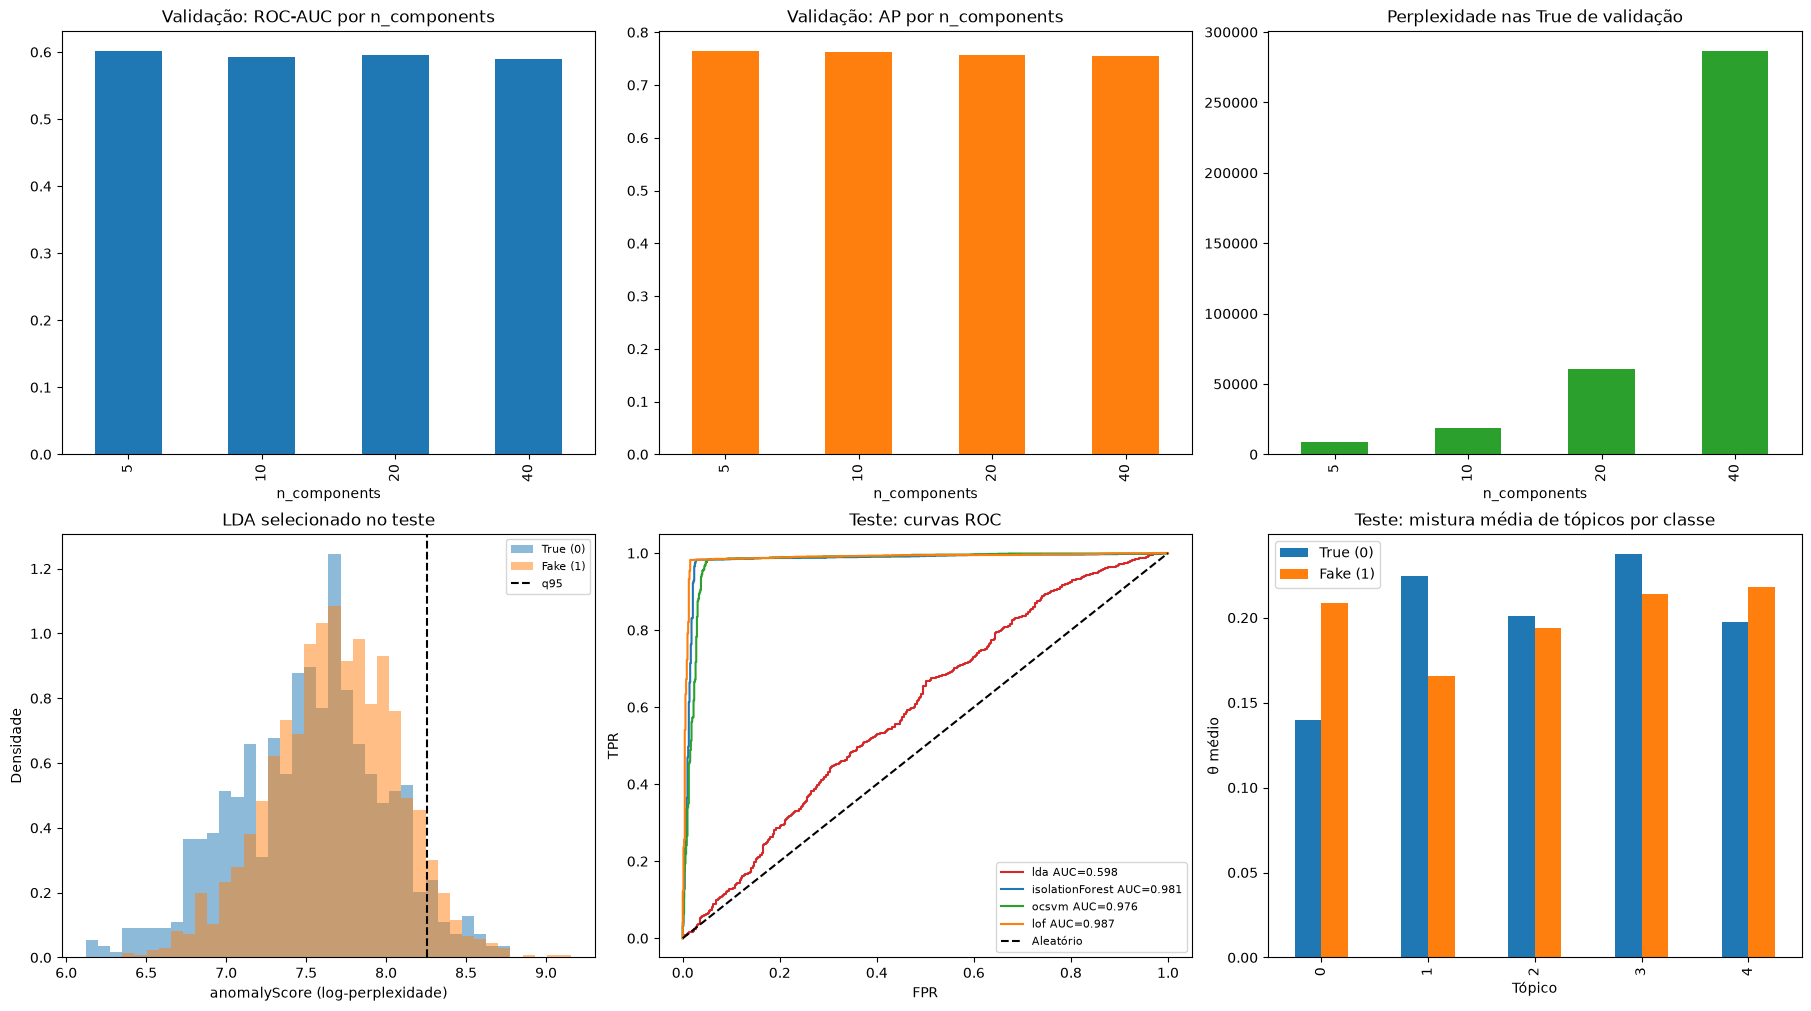

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
for axis, column, title, color in [
    (axes[0, 0], "validationRocAuc", "Validação: ROC-AUC por n_components", "tab:blue"),
    (axes[0, 1], "validationAveragePrecision", "Validação: AP por n_components", "tab:orange"),
    (axes[0, 2], "normalValidationPerplexity", "Perplexidade nas True de validação", "tab:green"),
]:
    validationResults.plot(x="n_components", y=column, kind="bar", ax=axis, title=title, legend=False, color=color)

testLabels = testPredictionsFrame["label"].to_numpy()
ldaScores = testPredictionsFrame["ldaAnomalyScore"].to_numpy()
scoreBins = np.histogram_bin_edges(ldaScores, bins=40)
for label, name, color in [(0, "True (0)", "tab:blue"), (1, "Fake (1)", "tab:orange")]:
    axes[1, 0].hist(ldaScores[testLabels == label], bins=scoreBins, density=True, alpha=0.5, label=name, color=color)
axes[1, 0].axvline(results["lda"]["threshold"], color="black", linestyle="--", label="q95")
axes[1, 0].set(title="LDA selecionado no teste", xlabel="anomalyScore (log-perplexidade)", ylabel="Densidade")
axes[1, 0].legend(fontsize=8)

for (model, result), color in zip(results.items(), ["tab:red", "tab:blue", "tab:green", "tab:orange"]):
    curveFpr, curveTpr, _ = roc_curve(testLabels, result["scores"])
    axes[1, 1].plot(curveFpr, curveTpr, label=f"{model} AUC={result['q95Metrics']['rocAuc']:.3f}", color=color)
axes[1, 1].plot([0, 1], [0, 1], "k--", label="Aleatório")
axes[1, 1].set(title="Teste: curvas ROC", xlabel="FPR", ylabel="TPR")
axes[1, 1].legend(fontsize=8)

testDocumentTopic = selectedPipeline["detector"].lda_.transform(
    selectedPipeline["vectorizer"].transform(testPredictionsFrame[TEXT_COLUMN])
)
pd.DataFrame(testDocumentTopic).groupby(testLabels).mean().rename(index={0: "True (0)", 1: "Fake (1)"}).T.plot(
    kind="bar", ax=axes[1, 2], color=["tab:blue", "tab:orange"], title="Teste: mistura média de tópicos por classe",
)
axes[1, 2].set(xlabel="Tópico", ylabel="θ médio")
plt.show()

## Casos extremos e discordâncias

Calculados depois de congelar o candidato LDA, usando o teste apenas como avaliação exploratória.

In [9]:
exampleColumns = ["id", "label", "ldaAnomalyScore", "ldaQ95IsAnomaly", TEXT_COLUMN]
for title, examples in extremeCases(testPredictionsFrame, "ldaAnomalyScore").items():
    display(Markdown(f"**{title}**"))
    display(examples[exampleColumns])

ldaRank = testPredictionsFrame["ldaAnomalyScore"].rank(ascending=False)
for control in ["isolationForest", "lof"]:
    rankDifference = (ldaRank - testPredictionsFrame[f"{control}AnomalyScore"].rank(ascending=False)).abs()
    display(Markdown(f"**LDA × {control}: maiores discordâncias de rank**"))
    display(
        testPredictionsFrame.assign(absoluteRankDifference=rankDifference)
        .nlargest(5, "absoluteRankDifference")[
            ["id", "label", "ldaAnomalyScore", f"{control}AnomalyScore", "absoluteRankDifference", TEXT_COLUMN]
        ]
    )

**5 True mais anômalas**

,id,label,ldaAnomalyScore,ldaQ95IsAnomaly,text
0,2304t,0,8.771150,True,John Le Carré fala sobre relação conturbada co...
1,221t,0,8.702960,True,Autoritarismo midiático\r\n\r\nO que Wyllys e ...
2,192t,0,8.658949,True,Leitora se queixa de mau sinal de internet\r\n...
3,1541t,0,8.640281,True,Rodrigo Fonseca Dublado por medalhões do pop ...
4,2352t,0,8.617807,True,Karl Jaspers analisa responsabilidade do povo ...


**5 Fake mais anômalas**

,id,label,ldaAnomalyScore,ldaQ95IsAnomaly,text
0,586,1,9.156377,True,"""Tô Feliz (Matei o Presidente)  versão 2  Ga..."
1,266,1,9.078816,True,"Psiquiatra emite diagnóstico de Lula: ""Persona..."
2,665,1,8.872512,True,"""Peladão"" do Museu de Arte Moderna deturpou e ..."
3,2062,1,8.756281,True,Ronaldo elogia esposa de jogador português e t...
4,631,1,8.745611,True,"""Lucro do Facebook é baseado em falsos engajam..."


**5 Fake menos anômalas**

,id,label,ldaAnomalyScore,ldaQ95IsAnomaly,text
0,1439,1,6.409407,False,Lula tenta escapar de Sérgio Moro (mais uma ve...
1,2204,1,6.422714,False,Escárnio! Lula se recusa a depor para Sérgio M...
2,1291,1,6.498763,False,Trump diz que conflito com a Coréia do Norte é...
3,1360,1,6.527013,False,EUA fazem voos de reconhecimento nos céus da C...
4,101,1,6.553809,False,URGENTE: Janot pede prisão de Aécio Neves. O p...


**LDA × isolationForest: maiores discordâncias de rank**

,id,label,ldaAnomalyScore,isolationForestAnomalyScore,absoluteRankDifference,text
690,644t,0,8.503335,-0.115778,2409.0,Tropkillaz: como o duo produziu Vai malandra e...
105,1729t,0,8.453198,-0.115858,2401.0,Corrida para encontrar vacina contra o zika te...
357,3530t,0,8.510191,-0.113964,2394.0,por Leandro de Oliveira O leitor da coluna “F...
262,1932t,0,8.369817,-0.117478,2393.5,Milhares protestam na Rússia após incêndio que...
1019,1070,1,6.829890,0.224214,2389.0,"STF manda soltar ""homem da mala"". Edson Fachi..."


**LDA × lof: maiores discordâncias de rank**

,id,label,ldaAnomalyScore,lofAnomalyScore,absoluteRankDifference,text
105,1729t,0,8.453198,-0.537169,2466.0,Corrida para encontrar vacina contra o zika te...
690,644t,0,8.503335,-0.528180,2455.0,Tropkillaz: como o duo produziu Vai malandra e...
1162,2155,1,6.703774,6.358039,2416.0,Tribunal Regional Federal da 4a. região nega h...
262,1932t,0,8.369817,-0.513179,2357.5,Milhares protestam na Rússia após incêndio que...
241,2000t,0,8.284766,-0.522410,2351.0,Profissionais que evitam roubadas. Envie sua p...


## Conclusão

In [10]:
selectedValidation = validationResults.set_index("modelKey").loc[selectedModelKey]
ldaQ95 = results["lda"]["q95Metrics"]
display(Markdown(f"""
O candidato congelado foi **{selectedModelKey}**, com ROC-AUC de validação
**{selectedValidation['validationRocAuc']:.4f}** e AP **{selectedValidation['validationAveragePrecision']:.4f}**.
No teste, LDA q95 obteve ROC-AUC **{ldaQ95['rocAuc']:.4f}**, AP **{ldaQ95['averagePrecision']:.4f}**,
recall **{ldaQ95['recall']:.2%}** e FPR **{ldaQ95['fpr']:.2%}**.

O ajuste usou **{len(partitions['normalTrain'])} True e nenhuma Fake**. A seleção usou labels Fake
somente na validação. O score mede quão atípico é o vocabulário/assunto em relação às True deste
corpus; não prova falsidade. O Fake.br foi montado com pares True/Fake sobre os mesmos assuntos,
então um detector baseado em tema tende a separar pouco as classes: as Fake ocupam os mesmos
tópicos das True. As features estilométricas (IF/OCSVM/LOF) capturam um sinal que o LDA não vê.
"""))


O candidato congelado foi **lda_topics_005**, com ROC-AUC de validação
**0.6018** e AP **0.7647**.
No teste, LDA q95 obteve ROC-AUC **0.5984**, AP **0.7625**,
recall **6.17%** e FPR **5.14%**.

O ajuste usou **2160 True e nenhuma Fake**. A seleção usou labels Fake
somente na validação. O score mede quão atípico é o vocabulário/assunto em relação às True deste
corpus; não prova falsidade. O Fake.br foi montado com pares True/Fake sobre os mesmos assuntos,
então um detector baseado em tema tende a separar pouco as classes: as Fake ocupam os mesmos
tópicos das True. As features estilométricas (IF/OCSVM/LOF) capturam um sinal que o LDA não vê.
